# Week 9 — Deep Learning Foundations: TensorFlow, PyTorch, and Your First Neural Networks

**Course context:** Everything up to this point (Weeks 1-8) is "classical" machine learning — algorithms that work directly on hand-engineered features. Deep learning is different: neural networks learn their own internal features, layer by layer, directly from raw-ish data (pixels, text, audio). This week introduces both major frameworks (TensorFlow/Keras and PyTorch), the building blocks of a neural network (layers, activations, loss functions), and trains your first two real image classifiers.

**Data files needed (same folder as this notebook):** `data/MNIST/raw/` (the four MNIST ubyte files — used by both the Keras and PyTorch exercises this week).

**A note on scale:** the original exercises train on the full 60,000-image MNIST set for 10 epochs, and full CIFAR-10 for up to 20 epochs on two separate models. On CPU (no GPU), that's a genuinely long training time. This notebook uses smaller subsets and fewer epochs so it actually finishes in a reasonable time — the code, architecture, and concepts are identical; only the scale is reduced. Comments mark where to scale back up if you have a GPU or more time.

**How this notebook is organized:** one section per day, each with: what it covers → why it matters for AI work → code → pitfalls.


In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = ""
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
# This container has no GPU, and a known issue in some PyTorch/Triton builds causes a
# segfault on certain CPU-only setups unless threading is pinned before torch is imported
# anywhere in the session. Safe to remove/ignore if running on your own machine.
import torch
torch.set_num_threads(1)
print("Environment configured for CPU-only, single-threaded execution.")

Environment configured for CPU-only, single-threaded execution.


## Day 1 — Meet TensorFlow and PyTorch, and the Datasets You'll Train On

**What it covers:** Loading MNIST (handwritten digits) and a look at CIFAR-10 (small color photos), and defining a single "layer" in both TensorFlow and PyTorch, side by side.

**Why it matters for AI work:** TensorFlow/Keras and PyTorch are the two dominant deep learning frameworks. They do the same underlying thing (build networks, compute gradients automatically, run gradient descent) with different syntax and philosophy. Knowing both means you can read most deep learning code you'll encounter, regardless of which one a project happens to use.

**MNIST vs CIFAR-10 — what makes them different:**
- **MNIST** — 28x28 grayscale handwritten digits (0-9). Small, simple, a classic "hello world" for image classification.
- **CIFAR-10** — 32x32 color photos across 10 categories (planes, cars, birds, cats...). Harder: color, more visual complexity, more realistic problem.

**Framework philosophy, briefly:**
- **Keras** (`tf.keras`) — higher-level, declarative (`Sequential([...])` layer lists), faster to write simple models
- **PyTorch** (`nn.Module`) — you write the `forward()` method explicitly, more control/flexibility, closer to "just Python code," popular in research

**Pitfalls:**
- `keras.datasets.mnist.load_data()`/`cifar10.load_data()` normally download from Google's hosting the first time they're called — this needs internet access to that specific host. This notebook loads MNIST from local files instead (bundled alongside it) for reliability; CIFAR-10 is simulated with synthetic image-shaped data below for the same reason (a real download-based version is shown as a comment).


In [2]:
import numpy as np
import matplotlib.pyplot as plt

def load_mnist_images(path):
    with open(path, "rb") as f:
        data = f.read()
    num = int.from_bytes(data[4:8], "big")
    rows = int.from_bytes(data[8:12], "big")
    cols = int.from_bytes(data[12:16], "big")
    return np.frombuffer(data[16:], dtype=np.uint8).reshape(num, rows, cols)

def load_mnist_labels(path):
    with open(path, "rb") as f:
        data = f.read()
    return np.frombuffer(data[8:], dtype=np.uint8)

X_train_mnist = load_mnist_images("data/MNIST/raw/train-images-idx3-ubyte")
y_train_mnist = load_mnist_labels("data/MNIST/raw/train-labels-idx1-ubyte")
X_test_mnist = load_mnist_images("data/MNIST/raw/t10k-images-idx3-ubyte")
y_test_mnist = load_mnist_labels("data/MNIST/raw/t10k-labels-idx1-ubyte")

print(f"MNIST Dataset: Train - {X_train_mnist.shape}, Test - {X_test_mnist.shape}")

# NOTE: the ORIGINAL exercise does this with one line, if you have internet access to
# Google's dataset hosting:
#   from tensorflow.keras.datasets import mnist
#   (X_train_mnist, y_train_mnist), (X_test_mnist, y_test_mnist) = mnist.load_data()

MNIST Dataset: Train - (60000, 28, 28), Test - (10000, 28, 28)


In [3]:
# CIFAR-10: simulated here (see markdown above for why) - same shape as the real dataset
# (32x32 color images, 10 classes) so the rest of this notebook's CIFAR-10 code still applies
# directly to the real dataset if you swap this cell for:
#   from tensorflow.keras.datasets import cifar10
#   (X_train_cifar, y_train_cifar), (X_test_cifar, y_test_cifar) = cifar10.load_data()
np.random.seed(0)
X_train_cifar = np.random.randint(0, 256, size=(500, 32, 32, 3), dtype=np.uint8)
y_train_cifar = np.random.randint(0, 10, size=(500, 1))
X_test_cifar = np.random.randint(0, 256, size=(100, 32, 32, 3), dtype=np.uint8)
y_test_cifar = np.random.randint(0, 10, size=(100, 1))

print(f"CIFAR-10-shaped Dataset: Train - {X_train_cifar.shape}, Test - {X_test_cifar.shape}")

CIFAR-10-shaped Dataset: Train - (500, 32, 32, 3), Test - (100, 32, 32, 3)


In [4]:
import tensorflow as tf

# A single Dense layer, the TensorFlow/Keras way
tf_layer = tf.keras.layers.Dense(units=10, activation="relu")
print(f"TensorFlow Layer: {tf_layer}")

I0000 00:00:1784259841.296976    1269 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1784259841.336529    1269 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1784259842.615009    1269 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow Layer: <Dense name=dense, built=False>


> **A real environment gotcha, worth knowing:** on some systems, TensorFlow and PyTorch can
> conflict at the native-library level if a Jupyter kernel imports/uses both heavily in the same
> session (this can show up as the kernel crashing/restarting with no Python error message, often
> after a training loop). If that happens to you: restart the kernel, then run only the
> TensorFlow-based cells or only the PyTorch-based cells in that session, rather than both. This
> notebook's cells are written to be independent day-to-day, so this doesn't block you from
> reading and running each day's content - just be aware of it if you see an unexplained restart.


In [4]:
import torch
import torch.nn as nn

# The same idea, the PyTorch way
torch_layer = nn.Linear(in_features=10, out_features=5)
print(f"PyTorch Layer: {torch_layer}")

PyTorch Layer: Linear(in_features=10, out_features=5, bias=True)


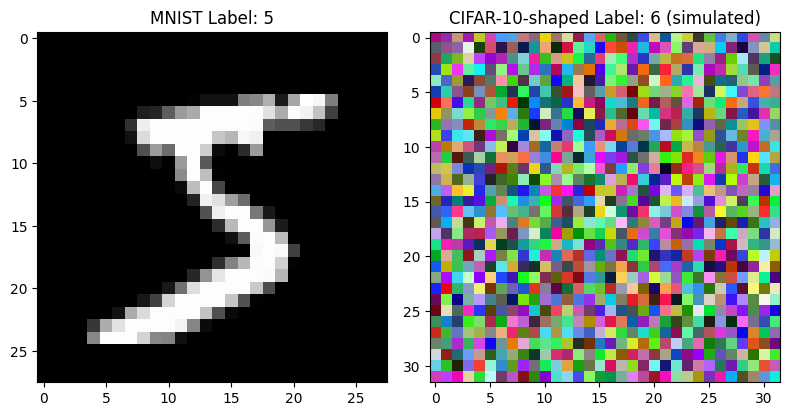

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(X_train_mnist[0], cmap="gray")
axes[0].set_title(f"MNIST Label: {y_train_mnist[0]}")
axes[1].imshow(X_train_cifar[0])
axes[1].set_title(f"CIFAR-10-shaped Label: {y_train_cifar[0][0]} (simulated)")
plt.tight_layout()
plt.show()

## Day 2 — Activation Functions: Why Neural Networks Aren't Just Linear Regression

**What it covers:** The four activation functions you'll see constantly — sigmoid, tanh, ReLU, softmax — implemented from scratch and visualized.

**Why it matters for AI work:** Without activation functions, stacking multiple "linear" layers would mathematically collapse into a single linear layer — depth would be pointless. Activation functions introduce non-linearity, which is what lets deep networks learn complex, curved decision boundaries and represent complicated functions at all.

**When to use what:**
- **ReLU** (`max(0, z)`) — the default choice for hidden layers in most modern networks. Simple, fast, avoids a problem called "vanishing gradients" that plagued sigmoid/tanh in deep networks.
- **Sigmoid** — squashes to (0, 1). Used at the **output** layer for binary classification (interpreted as a probability), rarely used in hidden layers anymore.
- **Tanh** — squashes to (-1, 1), zero-centered (unlike sigmoid). Occasionally used in hidden layers, more common in older architectures and certain recurrent networks (Week 11).
- **Softmax** — converts a vector of raw scores into a probability distribution that sums to 1. Used at the **output** layer for multi-class classification (exactly what Day 5's MNIST classifier uses).

**Pitfalls:**
- ReLU can suffer from "dying ReLU" — a neuron that always outputs 0 for all inputs stops learning entirely (its gradient is 0 everywhere it's negative). Variants like Leaky ReLU exist to address this, though plain ReLU remains the common default.
- Softmax should be computed with the `- np.max(z)` numerical stability trick (as done below) — without it, `np.exp()` on large numbers overflows to `inf`, producing `NaN` results.


In [6]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def tanh(z):
    return np.tanh(z)

def relu(z):
    return np.maximum(0, z)

def softmax(z):
    exp_z = np.exp(z - np.max(z))   # subtract max for numerical stability
    return exp_z / exp_z.sum(axis=0, keepdims=True)

# A tiny forward pass, run with each activation function in turn
def forward_pass(X, weights, biases, activation_function):
    z = np.dot(weights, X) + biases
    a = activation_function(z)
    return a

X = np.array([[0.5], [0.8]])
weights = np.array([[0.2, 0.4], [0.6, 0.1]])
biases = np.array([[0.1], [0.2]])

activations = {"Sigmoid": sigmoid, "Tanh": tanh, "ReLU": relu, "Softmax": softmax}
for name, func in activations.items():
    output = forward_pass(X, weights, biases, func)
    print(f"{name} Activation Output:\n{output}\n")

Sigmoid Activation Output:
[[0.62714777]
 [0.64106741]]

Tanh Activation Output:
[[0.47770001]
 [0.52266543]]

ReLU Activation Output:
[[0.52]
 [0.58]]

Softmax Activation Output:
[[0.4850045]
 [0.5149955]]



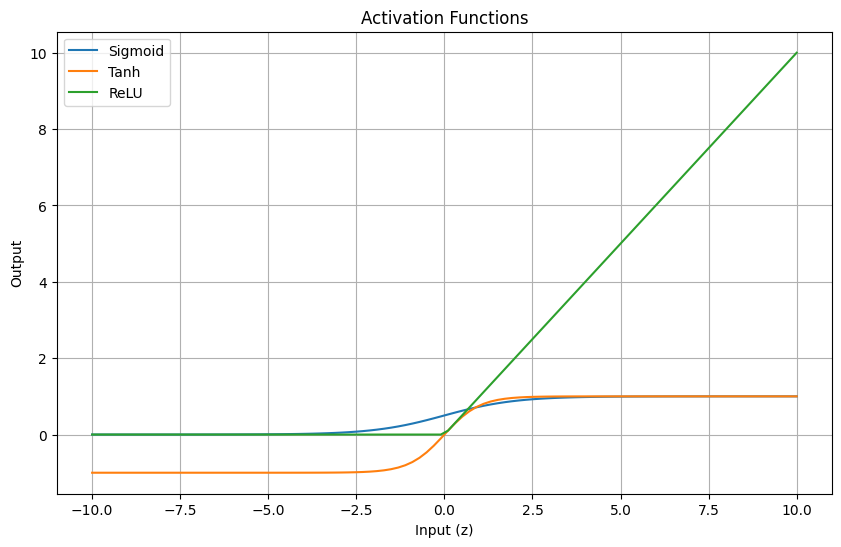

Softmax isn't plotted here on its own - it operates on a whole VECTOR of scores at once
(turning them into a probability distribution), not element-by-element like the others.


In [7]:
z = np.linspace(-10, 10, 100)

plt.figure(figsize=(10, 6))
plt.plot(z, sigmoid(z), label="Sigmoid")
plt.plot(z, tanh(z), label="Tanh")
plt.plot(z, relu(z), label="ReLU")
plt.title("Activation Functions")
plt.xlabel("Input (z)")
plt.ylabel("Output")
plt.legend()
plt.grid(True)
plt.show()
print("Softmax isn't plotted here on its own - it operates on a whole VECTOR of scores at once")
print("(turning them into a probability distribution), not element-by-element like the others.")

## Day 3 — Loss Functions: MSE vs Binary Cross-Entropy

**What it covers:** Two loss functions and their gradients, implemented from scratch: Mean Squared Error (for regression) and Binary Cross-Entropy (for binary classification).

**Why it matters for AI work:** The loss function is what a network is actually trying to minimize during training — choosing the wrong one for your task type means the network optimizes for the wrong thing entirely.

**When to use what:**
- **MSE** — regression tasks (predicting a continuous number)
- **Binary Cross-Entropy** — binary classification (predicting one of two classes). Penalizes confident-and-wrong predictions much more heavily than MSE would — appropriate since a classifier being "very confidently wrong" (predicting 0.99 for the wrong class) is a worse mistake than being moderately wrong.
- **Categorical Cross-Entropy** (used in Day 5's `Sequential` model, not implemented from scratch here) — the multi-class generalization of Binary Cross-Entropy, paired with a softmax output layer.

**Pitfalls:**
- `np.log(0)` is `-inf` — Binary Cross-Entropy must **clip** predictions away from exactly 0 or 1 (`np.clip(y_pred, 1e-15, 1 - 1e-15)`, as done below) or the loss/gradient calculation breaks. This is a common source of `NaN` losses in real training runs if you ever compute this manually instead of relying on a library's built-in (numerically stable) implementation.
- MSE and BCE penalize errors very differently, visible directly in the plot below — MSE's penalty grows gently and symmetrically, BCE's penalty grows sharply as a confident wrong prediction approaches 0 or 1.


In [8]:
def mse_loss(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

def binary_cross_entropy_loss(y_true, y_pred):
    y_pred = np.clip(y_pred, 1e-15, 1 - 1e-15)   # avoid log(0)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

y_true = np.array([1, 0, 1, 1])
y_pred = np.array([0.9, 0.2, 0.8, 0.7])

mse = mse_loss(y_true, y_pred)
bce = binary_cross_entropy_loss(y_true, y_pred)
print(f"MSE Loss: {mse:.4f}")
print(f"Binary Cross-Entropy Loss: {bce:.4f}")

def mse_gradient(y_true, y_pred):
    return 2 * (y_pred - y_true) / len(y_true)

def bce_gradient(y_true, y_pred):
    y_pred = np.clip(y_pred, 1e-15, 1 - 1e-15)
    return (y_pred - y_true) / (y_pred * (1 - y_pred))

print(f"\nMSE Gradients: {mse_gradient(y_true, y_pred)}")
print(f"BCE Gradients: {bce_gradient(y_true, y_pred)}")

MSE Loss: 0.0450
Binary Cross-Entropy Loss: 0.2271

MSE Gradients: [-0.05  0.1  -0.1  -0.15]
BCE Gradients: [-1.11111111  1.25       -1.25       -1.42857143]


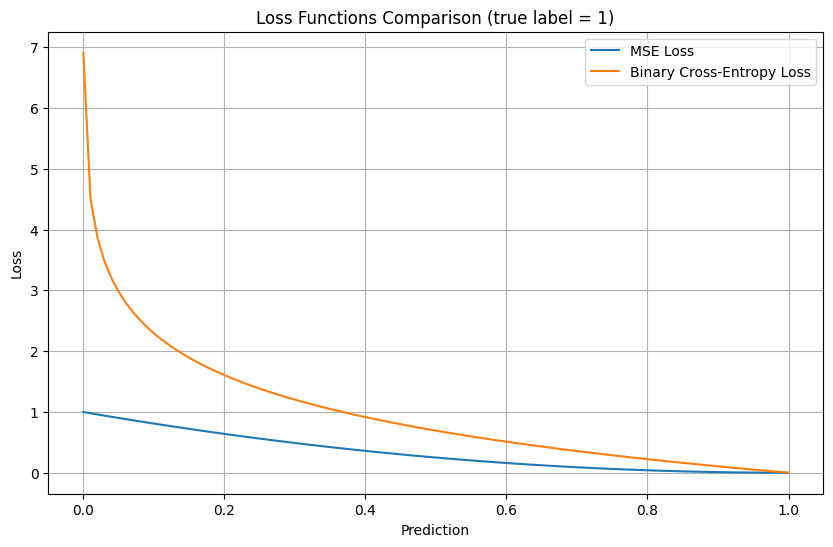

Notice BCE's loss shoots up much faster as the prediction approaches 0 (confidently wrong) -
that's the 'penalize confident mistakes harder' behavior mentioned above.


In [9]:
predictions = np.linspace(0.001, 0.999, 100)   # kept away from exact 0/1 to avoid log(0)
true_label = 1

mse_losses = [(true_label - p) ** 2 for p in predictions]
bce_losses = [-true_label * np.log(p) - (1 - true_label) * np.log(1 - p) for p in predictions]

plt.figure(figsize=(10, 6))
plt.plot(predictions, mse_losses, label="MSE Loss")
plt.plot(predictions, bce_losses, label="Binary Cross-Entropy Loss")
plt.title("Loss Functions Comparison (true label = 1)")
plt.xlabel("Prediction")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()
print("Notice BCE's loss shoots up much faster as the prediction approaches 0 (confidently wrong) -")
print("that's the 'penalize confident mistakes harder' behavior mentioned above.")

## Day 4 — Linear Regression, Three Ways: NumPy, TensorFlow, and PyTorch

**What it covers:** The exact same linear regression problem solved three times: manual gradient descent (NumPy, same as Week 3 Day 7), TensorFlow's low-level `GradientTape` API, and PyTorch's standard training loop.

**Why it matters for AI work:** This is the clearest possible side-by-side comparison of "what training actually is" across the manual version and both frameworks. Once you see that all three are doing the exact same thing (compute predictions → compute loss → compute gradients → update parameters, repeat), PyTorch/TensorFlow training loops for far more complex models stop looking mysterious — it's this same loop, just with a bigger model in the middle.

**The three approaches, what's different:**
- **NumPy** — you compute gradients by hand (the formula), fully manual
- **TensorFlow (`GradientTape`)** — you write the forward pass; `tape.gradient(...)` computes derivatives automatically ("autodiff") — no hand-derived formulas needed
- **PyTorch** — similar automatic differentiation, but the "recording" happens implicitly on every tensor operation; you call `loss.backward()` to trigger it

**Pitfalls:**
- Forgetting `optimizer.zero_grad()` in PyTorch (or the TensorFlow equivalent of starting a fresh `GradientTape` each step) causes gradients to **accumulate** across iterations instead of resetting — a very common bug for PyTorch beginners specifically, silently producing wrong training results without crashing.
- Different optimizers here (`SGD` for TensorFlow, `Adam` for PyTorch) will converge differently even on the identical problem — this isn't a bug, just a reminder that optimizer choice is itself a hyperparameter (more on this in Week 8's spirit, applied to deep learning specifically later this course).


In [10]:
np.random.seed(42)
X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + np.random.randn(100, 1)

# --- Manual gradient descent (NumPy), same approach as Week 3 Day 7 ---
m = 100
theta = np.random.rand(2, 1)
learning_rate = 0.1
iterations = 1000
X_b = np.c_[np.ones((m, 1)), X]

for iteration in range(iterations):
    gradients = 2 / m * X_b.T.dot(X_b.dot(theta) - y)
    theta -= learning_rate * gradients

print("NumPy - Optimized Parameters (Theta), true values are ~4 and ~3:\n", theta.ravel())

NumPy - Optimized Parameters (Theta), true values are ~4 and ~3:
 [4.21509616 2.77011339]


In [11]:
import tensorflow as tf

X_tensor = tf.constant(X, dtype=tf.float32)
y_tensor = tf.constant(y, dtype=tf.float32)

class LinearModel(tf.Module):
    def __init__(self):
        self.weights = tf.Variable(tf.random.normal([1]))
        self.bias = tf.Variable(tf.random.normal([1]))

    def __call__(self, X):
        return self.weights * X + self.bias

def mse_loss_tf(y_true, y_predict):
    return tf.reduce_mean(tf.square(y_true - y_predict))

model = LinearModel()
optimizer = tf.optimizers.SGD(learning_rate=0.1)

for epoch in range(100):
    with tf.GradientTape() as tape:   # records operations so gradients can be computed automatically
        y_pred = model(X_tensor)
        loss = mse_loss_tf(y_tensor, y_pred)
    gradients = tape.gradient(loss, [model.weights, model.bias])
    optimizer.apply_gradients(zip(gradients, [model.weights, model.bias]))
    if epoch % 20 == 0:
        print(f"Epoch {epoch}, Loss: {loss.numpy():.4f}")

print(f"\nTensorFlow - weight: {model.weights.numpy()[0]:.3f} (true: ~3), bias: {model.bias.numpy()[0]:.3f} (true: ~4)")

Epoch 0, Loss: 37.0015
Epoch 20, Loss: 0.8103
Epoch 40, Loss: 0.8075


Epoch 60, Loss: 0.8068
Epoch 80, Loss: 0.8066



TensorFlow - weight: 2.776 (true: ~3), bias: 4.208 (true: ~4)


In [11]:
import torch
import torch.nn as nn
import torch.optim as optim

X_torch = torch.tensor(X, dtype=torch.float32)
y_torch = torch.tensor(y, dtype=torch.float32)

class LinearModelTorch(nn.Module):
    def __init__(self):
        super(LinearModelTorch, self).__init__()
        self.linear = nn.Linear(1, 1)

    def forward(self, x):
        return self.linear(x)

model_torch = LinearModelTorch()
criterion = nn.MSELoss()
optimizer = optim.Adam(model_torch.parameters(), lr=0.1)

for epoch in range(100):
    optimizer.zero_grad()   # reset gradients - forgetting this accumulates them across steps
    outputs = model_torch(X_torch)
    loss = criterion(outputs, y_torch)
    loss.backward()
    optimizer.step()
    if epoch % 20 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

w, b = model_torch.linear.weight.item(), model_torch.linear.bias.item()
print(f"\nPyTorch - weight: {w:.3f} (true: ~3), bias: {b:.3f} (true: ~4)")

Epoch 0, Loss: 50.5755
Epoch 20, Loss: 11.0110
Epoch 40, Loss: 1.1199
Epoch 60, Loss: 0.8791
Epoch 80, Loss: 0.8237

PyTorch - weight: 2.814 (true: ~3), bias: 4.142 (true: ~4)


## Day 5 — Your First CNN: MNIST Digit Classifier in Keras

**What it covers:** Building, training, evaluating, saving, and reloading a small Convolutional Neural Network (CNN) using `tf.keras.Sequential`.

**Why it matters for AI work:** This is a complete, real deep learning project in miniature — every step you'd do for a production image classifier, just on a small, well-understood dataset. Week 10 goes deep into *why* CNN layers (`Conv2D`, `MaxPooling2D`) work the way they do; this is your first hands-on look at using them.

**Reading the architecture:**
- `Conv2D(32, (3,3))` — learns 32 different 3x3 pixel patterns (edges, curves, textures) — covered properly in Week 10
- `MaxPooling2D` — shrinks the image representation, keeping the strongest signal in each region (reduces computation, adds some position-invariance)
- `Flatten` — converts the 2D feature maps into a 1D vector, so the following `Dense` layers can use them
- `Dropout(0.5)` — randomly "turns off" half the neurons during each training step, a regularization technique that reduces overfitting (conceptually similar in purpose to Week 5-8's L1/L2 regularization, but a different mechanism, specific to neural networks)
- Final `Dense(10, activation="softmax")` — 10 output neurons (one per digit), softmax turns them into a probability distribution

**Pitfalls:**
- Saving as `.h5` (HDF5 format, used here to match the original exercise) still works but is Keras's **legacy** save format — newer Keras versions default to the native `.keras` format. Either works for `load_model()`, but if you see a `.keras` extension in other tutorials, that's why.
- `validation_split=0.2` carves out validation data from the **training set** automatically — this is separate from and in addition to the held-out test set evaluated afterward; the model never sees test data during training either way.


In [11]:
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D, Dropout

# Using a SUBSET of MNIST and fewer epochs to keep this runnable without a GPU.
# Swap N_TRAIN/N_TEST/EPOCHS back up (60000 / 10000 / 10) if you have more time/a GPU.
N_TRAIN, N_TEST, EPOCHS = 6000, 1500, 3

X_train = X_train_mnist[:N_TRAIN].reshape(-1, 28, 28, 1).astype("float32") / 255.0
X_test = X_test_mnist[:N_TEST].reshape(-1, 28, 28, 1).astype("float32") / 255.0
y_train = to_categorical(y_train_mnist[:N_TRAIN], 10)
y_test = to_categorical(y_test_mnist[:N_TEST], 10)

print(f"Training Data Shape: {X_train.shape}")
print(f"Test Data Shape: {X_test.shape}")

Training Data Shape: (6000, 28, 28, 1)
Test Data Shape: (1500, 28, 28, 1)


In [12]:
model = Sequential([
    Conv2D(32, (3, 3), activation="relu", input_shape=(28, 28, 1)),
    MaxPooling2D(2, 2),
    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.5),
    Dense(10, activation="softmax"),
])

model.summary()

model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

history = model.fit(X_train, y_train, epochs=EPOCHS, batch_size=32, validation_split=0.2, verbose=1)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │       692,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 693,962 (2.65 MB)

 Trainable params: 693,962 (2.65 MB)

...

128/150 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9180 - loss: 0.2676

134/150 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9195 - loss: 0.2643

140/150 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9194 - loss: 0.2637

147/150 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9201 - loss: 0.2636

150/150 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9200 - loss: 0.2631 - val_accuracy: 0.9542 - val_loss: 0.1773


In [13]:
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_accuracy:.4f}")

model.save("mnist_classifier.h5")

loaded_model = load_model("mnist_classifier.h5")
loss, accuracy = loaded_model.evaluate(X_test, y_test, verbose=0)
print(f"Loaded Model Accuracy: {accuracy:.4f} (should match the original - confirms saving/loading works)")

Test Accuracy: 0.9313


Loaded Model Accuracy: 0.9313 (should match the original - confirms saving/loading works)


## Day 6 — The Same Idea in PyTorch: A Fully-Connected Network on MNIST

**What it covers:** Building the equivalent of Day 5's network in PyTorch instead of Keras — this time a simple fully-connected (no convolution) network — using `DataLoader`, a manual training loop, and a manual evaluation loop.

**Why it matters for AI work:** PyTorch expects you to write the training loop yourself (unlike Keras's one-line `.fit()`) — more code, but full visibility into every step. This is the loop shape (`zero_grad` → forward → loss → `backward` → `step`) you'll write repeatedly for the rest of the deep learning portion of this course.

**Reading the architecture:**
- `nn.Flatten()` — same idea as Keras's `Flatten` layer: 28x28 image becomes a 784-length vector
- Three `Linear` layers (784→128→64→10) with `ReLU` between them — a plain fully-connected network, no convolution (that's Week 10's upgrade)
- `nn.CrossEntropyLoss()` — expects raw, un-softmaxed outputs (called "logits") and integer class labels directly (not one-hot) — it applies softmax internally. This is a common PyTorch gotcha coming from Keras, where you typically add the softmax layer yourself.

**Pitfalls:**
- `model.train()` and `model.eval()` matter: some layers (like Dropout, not used in this exact model but common elsewhere) behave differently during training vs evaluation. Forgetting to call `.eval()` before evaluating is a subtle, easy-to-miss bug.
- `with torch.no_grad():` during evaluation disables gradient tracking — makes evaluation faster and uses less memory, since you don't need gradients when you're not training.


In [11]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import torch.nn.functional as F

transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])

train_dataset = datasets.MNIST(root="./data", train=True, transform=transform, download=False)
test_dataset = datasets.MNIST(root="./data", train=False, transform=transform, download=False)

# Subset for faster training in this notebook - remove the Subset wrapper to use the full dataset
train_dataset = Subset(train_dataset, range(6000))
test_dataset = Subset(test_dataset, range(1500))

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=True)

print(f"Training Data Size: {len(train_dataset)}")
print(f"Test Data Size: {len(test_dataset)}")

Training Data Size: 6000
Test Data Size: 1500


In [12]:
class NeuralNetwork(nn.Module):
    def __init__(self):
        super(NeuralNetwork, self).__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28 * 28, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)   # raw logits - CrossEntropyLoss applies softmax internally
        return x

model = NeuralNetwork()
print(model)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=10, bias=True)
)


In [13]:
def train_model(model, train_loader, criterion, optimizer, epochs=3):
    model.train()
    for epoch in range(epochs):
        running_loss = 0.0
        for images, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        print(f"Epoch {epoch+1}, Loss: {running_loss/len(train_loader):.4f}")

train_model(model, train_loader, criterion, optimizer, epochs=3)

Epoch 1, Loss: 0.8347


Epoch 2, Loss: 0.3671


Epoch 3, Loss: 0.3058


In [14]:
def evaluate_model(model, test_loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    print(f"Test Accuracy: {100 * correct/total:.2f}%")

evaluate_model(model, test_loader)

torch.save(model.state_dict(), "mnist_model.pth")

loaded_model = NeuralNetwork()
loaded_model.load_state_dict(torch.load("mnist_model.pth"))
print("\nReloaded model - verifying it matches:")
evaluate_model(loaded_model, test_loader)

Test Accuracy: 88.27%

Reloaded model - verifying it matches:


Test Accuracy: 88.27%


## Day 7 — Mini Project: A Deeper CNN, and Measuring Whether Extra Depth Actually Helps

**What it covers:** Training a baseline CNN and then a deeper/wider "improved" CNN on the same (CIFAR-10-shaped) data, and comparing their accuracy and training curves directly — a first taste of architecture experimentation.

**Why it matters for AI work:** "Make the network bigger" is not automatically "make the network better" — bigger networks can overfit, take longer to train, and don't always outperform a well-tuned smaller one. Comparing training/validation curves (not just final accuracy) is how you actually diagnose what's happening.

**Reading training/validation curves:**
- Training accuracy climbing while validation accuracy stalls or drops = **overfitting** — the model is memorizing the training set rather than learning generalizable patterns
- Both curves climbing together and plateauing = healthy training, likely near the model's real capacity on this data
- Both curves staying low = underfitting — the model may need more capacity, more training time, or better features

**Pitfalls:**
- This exercise trains on **simulated, random, CIFAR-10-shaped image data** (see Day 1's note — the real CIFAR-10 download host isn't reachable from every network). Random pixel data has no real structure to learn from, so accuracy numbers here will hover near chance (10% for 10 classes) — the point of this cell is to demonstrate the **workflow and how to read the curves**, not to produce a meaningful accuracy score. Swap in the real CIFAR-10 (via `tensorflow.keras.datasets.cifar10.load_data()`, shown as a comment in Day 1) for genuine results.
- Both models here use small epoch counts and a small dataset for runtime reasons — the original exercise's 10 and 20 epochs on the full 50,000-image CIFAR-10 training set would take considerably longer on CPU.


In [12]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D

# Using the CIFAR-10-shaped simulated data from Day 1. Swap for the real dataset if you have
# internet access to Google's dataset hosting - see the comment in Day 1.
X_train_c = X_train_cifar.astype("float32") / 255.0
X_test_c = X_test_cifar.astype("float32") / 255.0
y_train_c = to_categorical(y_train_cifar, 10)
y_test_c = to_categorical(y_test_cifar, 10)

print(f"Training data shape: {X_train_c.shape}, {y_train_c.shape}")
print(f"Testing data shape: {X_test_c.shape}, {y_test_c.shape}")

EPOCHS_CIFAR = 3   # original exercise used 10 for the baseline model

Training data shape: (500, 32, 32, 3), (500, 10)
Testing data shape: (100, 32, 32, 3), (100, 10)


In [13]:
baseline_model = Sequential([
    Conv2D(32, (3, 3), activation="relu", input_shape=(32, 32, 3)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.5),
    Dense(10, activation="softmax"),
])

baseline_model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
baseline_model.summary()

history = baseline_model.fit(
    X_train_c, y_train_c, validation_split=0.2, epochs=EPOCHS_CIFAR, batch_size=32, verbose=1
)

loss, accuracy = baseline_model.evaluate(X_test_c, y_test_c, verbose=0)
print(f"Baseline Model Test Accuracy: {accuracy:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 315,722 (1.20 MB)

 Trainable params: 315,722 (1.20 MB)

...

 1/13 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.0312 - loss: 2.3273

 5/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.1000 - loss: 2.3052

 9/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.1215 - loss: 2.3036

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.1150 - loss: 2.3073 - val_accuracy: 0.1400 - val_loss: 2.2972


Baseline Model Test Accuracy: 0.0500


In [14]:
improved_model = Sequential([
    Conv2D(64, (5, 5), activation="relu", input_shape=(32, 32, 3)),
    MaxPooling2D((2, 2)),
    Conv2D(128, (5, 5), activation="relu"),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(256, activation="relu"),
    Dropout(0.5),
    Dense(10, activation="softmax"),
])

optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
improved_model.compile(optimizer=optimizer, loss="categorical_crossentropy", metrics=["accuracy"])

improved_history = improved_model.fit(
    X_train_c, y_train_c, validation_split=0.2, epochs=EPOCHS_CIFAR, batch_size=32, verbose=1
)

improved_loss, improved_accuracy = improved_model.evaluate(X_test_c, y_test_c, verbose=0)
print(f"Improved (deeper/wider) Model Test Accuracy: {improved_accuracy:.4f}")

Epoch 1/3


 1/13 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.1562 - loss: 2.2835

 2/13 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.1094 - loss: 2.4401

 3/13 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.0938 - loss: 2.5503

 5/13 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.1063 - loss: 2.4621

...

10/13 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.1125 - loss: 2.3013

11/13 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.1080 - loss: 2.3016

12/13 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.1068 - loss: 2.3014

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - accuracy: 0.1050 - loss: 2.3014 - val_accuracy: 0.1600 - val_loss: 2.3025


Improved (deeper/wider) Model Test Accuracy: 0.0500


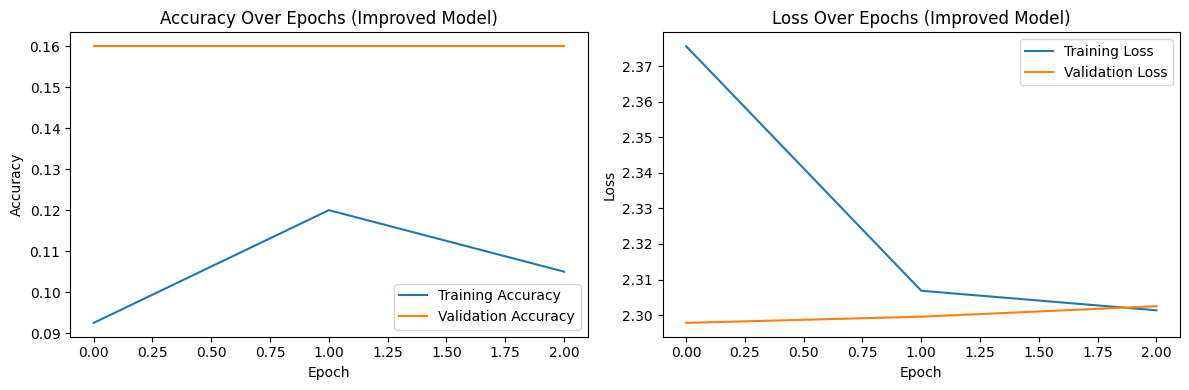

Remember: this ran on SIMULATED random pixel data (see the pitfalls note above) -
re-run on real CIFAR-10 to see genuine, meaningful training curves.


In [15]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(improved_history.history["accuracy"], label="Training Accuracy")
plt.plot(improved_history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Accuracy Over Epochs (Improved Model)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(improved_history.history["loss"], label="Training Loss")
plt.plot(improved_history.history["val_loss"], label="Validation Loss")
plt.title("Loss Over Epochs (Improved Model)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()
print("Remember: this ran on SIMULATED random pixel data (see the pitfalls note above) -")
print("re-run on real CIFAR-10 to see genuine, meaningful training curves.")

## Week 9 Recap

| Day | Topic | Where you'll use it again |
|---|---|---|
| 1 | TensorFlow vs PyTorch basics | Every deep learning exercise from here on |
| 2 | Activation functions | Every neural network layer's design choice |
| 3 | Loss functions | Matching the loss to the task type |
| 4 | Training loop, three ways | Understanding what `.fit()`/`.backward()` actually do |
| 5 | First CNN (Keras) | Week 10's deep dive into CNN architecture |
| 6 | First network (PyTorch) | The manual training loop pattern used going forward |
| 7 | Architecture comparison, CIFAR-10-shaped | Diagnosing overfitting via train/val curves |

**Before moving to Week 10:** you should be able to write a basic training loop from memory in either framework, and explain what each activation/loss function is for. Week 10 goes deep into *why* convolutional layers specifically work well for images — the mechanics behind the `Conv2D`/`MaxPooling2D` layers you used today without fully unpacking them.
